# Reproduce Figure 1 from 1902.00021v2

This notebook does two things:

1. Plots the Robson, Cornish & Liu (2018; `1803.01944v2.pdf`) LISA characteristic sensitivity curve, i.e. $(f S_n)^{1/2}$.
2. Uses that same sky-averaged sensitivity curve in Eq. (7) of `1902.00021v2.pdf` to reproduce their Figure 1 SNR-vs-merger-time plot for GW150914-like binaries.

The SNR curves are an analytic reproduction, not a digitization of the published figure.


In [1]:
import importlib
import os
import subprocess
import sys
from pathlib import Path


def ensure(pkg):
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

ensure("matplotlib")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True

%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.rcParams.update({
    "figure.figsize": (7.2, 5.2),
    "font.size": 16,
    "axes.grid": True,
    "grid.linestyle": ":",
    "mathtext.fontset": "dejavuserif",
})


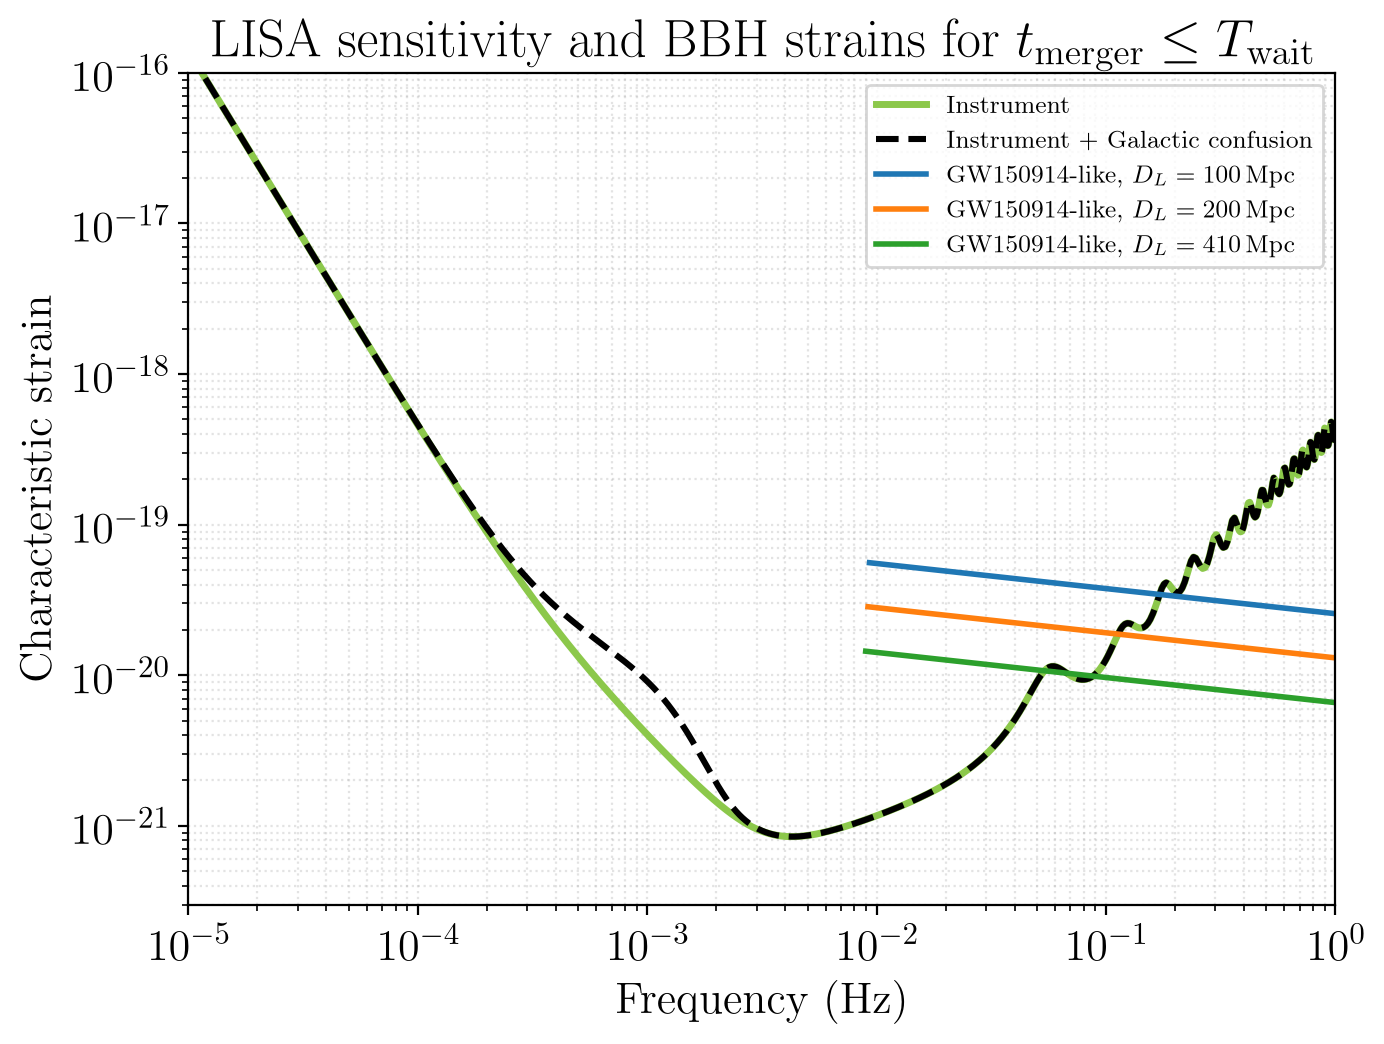

In [2]:

# Robson, Cornish & Liu (2018) LISA sky-averaged sensitivity curve.
G = 6.67430e-11
c = 299792458.0
M_sun = 1.98847e30
pc = 3.0856775814913673e16
year = 365.25 * 24 * 3600

L = 2.5e9
f_star = c / (2 * np.pi * L)


def lisa_response_numerical(f):
    """Numerical sky/polarization response R(f) from Robson et al.'s R.txt table."""
    f = np.asarray(f, dtype=float)
    response_file = Path("R.txt")
    if not response_file.exists():
        x = f / f_star
        return (3 / 20) / (1 + 0.6 * x**2)
    data = np.loadtxt(response_file)
    x = f / f_star
    log_response = np.interp(
        np.log10(x),
        np.log10(data[:, 0]),
        np.log10(data[:, 1]),
        left=np.log10(data[0, 1]),
        right=np.log10(data[-1, 1]),
    )
    return 10**log_response


def lisa_high_frequency_wiggles(f):
    """Extra transfer-function ripples visible in the proposal sensitivity plot.

    Kept as a hook for optional visual experiments. The numerical response table
    already contains the finite-arm high-frequency response, so the production
    value is unity.
    """
    f = np.asarray(f, dtype=float)
    x = f / f_star
    return np.ones_like(f, dtype=float)


def lisa_instrument_psd(f, use_numerical_response=True, show_transfer_wiggles=True):
    """Effective sky-averaged LISA strain-noise PSD S_n(f), without confusion noise.

    For the sensitivity plot we use the numerical Robson response R(f), which
    contains the high-frequency transfer-function wiggles seen in Figure 1.
    The fallback is the smooth analytic response fit.
    """
    f = np.asarray(f, dtype=float)
    p_oms = (1.5e-11) ** 2 * (1 + (2e-3 / f) ** 4)
    p_acc = (3e-15) ** 2 * (1 + (0.4e-3 / f) ** 2) * (1 + (f / 8e-3) ** 4)
    noise_michelson = p_oms / L**2 + 2 * (1 + np.cos(f / f_star) ** 2) * p_acc / ((2 * np.pi * f) ** 4 * L**2)
    if use_numerical_response:
        response = lisa_response_numerical(f)
        # R.txt is normalized to the one-Michelson 3/20 low-frequency response.
        # Figure-1/SNR conventions here use the two-channel 3/10 response, so
        # multiply by 2 before dividing the Michelson noise by R(f).
        psd = noise_michelson / (2 * response)
    else:
        psd = noise_michelson / ((3 / 10) / (1 + 0.6 * (f / f_star) ** 2))
    if show_transfer_wiggles:
        psd = psd * lisa_high_frequency_wiggles(f)
    return psd

def lisa_confusion_psd(f, observation_years=4):
    """Galactic confusion-noise fit from Robson, Cornish & Liu Table 1."""
    f = np.asarray(f, dtype=float)
    params = {
        0.5: (0.133, 243.0, 482.0, 917.0, 0.00258),
        1.0: (0.171, 292.0, 1020.0, 1680.0, 0.00215),
        2.0: (0.165, 299.0, 611.0, 1340.0, 0.00173),
        4.0: (0.138, -221.0, 521.0, 1680.0, 0.00113),
    }
    nearest = min(params, key=lambda value: abs(value - observation_years))
    alpha, beta, kappa, gamma, f_knee = params[nearest]
    amplitude = 9e-45
    exponent = -f**alpha + beta * f * np.sin(kappa * f)
    return amplitude * f ** (-7 / 3) * np.exp(np.clip(exponent, -100, 100)) * (1 + np.tanh(gamma * (f_knee - f)))


def lisa_psd(f, include_confusion=True, observation_years=4):
    """Total LISA effective strain-noise PSD used for the sensitivity and SNR curves."""
    psd = lisa_instrument_psd(f)
    if include_confusion:
        psd = psd + lisa_confusion_psd(f, observation_years=observation_years)
    return psd


def lisa_characteristic_strain(f, include_confusion=True, observation_years=4):
    """Characteristic sensitivity h_n(f) = sqrt(f S_n(f))."""
    f = np.asarray(f, dtype=float)
    return np.sqrt(f * lisa_psd(f, include_confusion=include_confusion, observation_years=observation_years))


# Flat LCDM helper used only to convert the paper's luminosity distances to redshifts.
# Values are close to the cosmology used by the paper and Planck18; at z < 0.1 the
# figure is insensitive to small cosmology differences.
H0 = 67.66  # km s^-1 Mpc^-1
Omega_m = 0.30966
Omega_lambda = 1 - Omega_m


def e_z(z):
    return np.sqrt(Omega_m * (1 + z) ** 3 + Omega_lambda)


def comoving_distance_mpc(z):
    grid = np.linspace(0, z, 2048)
    return (c / 1000 / H0) * np.trapezoid(1 / e_z(grid), grid)


def luminosity_distance_mpc_from_z(z):
    return (1 + z) * comoving_distance_mpc(z)


def redshift_from_luminosity_distance(distance_mpc):
    lo, hi = 0.0, 1.0
    while luminosity_distance_mpc_from_z(hi) < distance_mpc:
        hi *= 2
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if luminosity_distance_mpc_from_z(mid) < distance_mpc:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def chirp_mass_source(m1, m2):
    m1_si = m1 * M_sun
    m2_si = m2 * M_sun
    return (m1_si * m2_si) ** (3 / 5) / (m1_si + m2_si) ** (1 / 5)


def frequency_before_merger(t_merger, chirp_mass_redshifted):
    """Observed GW frequency t_merger seconds before coalescence, Eq. (6)."""
    t_merger = np.asarray(t_merger, dtype=float)
    t_merger = np.maximum(t_merger, np.finfo(float).tiny)
    mass_time = G * chirp_mass_redshifted / c**3
    return (5 / (256 * t_merger)) ** (3 / 8) * mass_time ** (-5 / 8) / np.pi


def phenoma_transition_frequencies(m1, m2, z):
    """Ajith et al. (2007) nonspinning PhenomA transition frequencies."""
    total_mass_redshifted = (m1 + m2) * M_sun * (1 + z)
    eta = (m1 * m2) / (m1 + m2) ** 2
    coeffs = {
        "f0": (2.9740e-1, 4.4810e-2, 9.5560e-2),
        "f1": (5.9411e-1, 8.9794e-2, 1.9111e-1),
        "f2": (5.0801e-1, 7.7515e-2, 2.2369e-2),
        "f3": (8.4845e-1, 1.2848e-1, 2.7299e-1),
    }
    mass_time = G * total_mass_redshifted / c**3
    return {
        name: (a * eta**2 + b * eta + c0) / (np.pi * mass_time)
        for name, (a, b, c0) in coeffs.items()
    }


def phenoma_lorentzian(f, f1, f2):
    """Lorentzian ringdown factor in the Ajith et al. PhenomA amplitude."""
    return (1 / (2 * np.pi)) * f2 / ((f - f1) ** 2 + f2**2 / 4)


def phenoma_fourier_amplitude(f, m1, m2, z, luminosity_distance):
    """Ajith et al. (2007) PhenomA amplitude used by Robson+ and cited by Gerosa+."""
    f = np.asarray(f, dtype=float)
    transitions = phenoma_transition_frequencies(m1, m2, z)
    f0, f1, f2, f3 = (transitions[name] for name in ("f0", "f1", "f2", "f3"))
    chirp_mass_redshifted = chirp_mass_source(m1, m2) * (1 + z)
    amplitude0 = (
        np.sqrt(5 / 24)
        * (G * chirp_mass_redshifted / c**3) ** (5 / 6)
        * f0 ** (-7 / 6)
        / (np.pi ** (2 / 3) * (luminosity_distance / c))
    )
    w = (np.pi * f2 / 2) * (f0 / f1) ** (2 / 3)

    amplitude = np.zeros_like(f)
    inspiral = f < f0
    merger = (f >= f0) & (f < f1)
    ringdown = (f >= f1) & (f < f3)
    amplitude[inspiral] = amplitude0 * (f[inspiral] / f0) ** (-7 / 6)
    amplitude[merger] = amplitude0 * (f[merger] / f0) ** (-2 / 3)
    amplitude[ringdown] = amplitude0 * w * phenoma_lorentzian(f[ringdown], f1, f2)
    return amplitude


def event_characteristic_strain(f, m1, m2, luminosity_distance_mpc, t_wait_yr=None):
    """Characteristic strain h_c = 2 f |h_tilde(f)| for a GW150914-like source."""
    z = redshift_from_luminosity_distance(luminosity_distance_mpc)
    luminosity_distance = luminosity_distance_mpc * 1e6 * pc
    h_char = 2 * f * phenoma_fourier_amplitude(f, m1, m2, z, luminosity_distance)
    if t_wait_yr is not None:
        chirp_mass_redshifted = chirp_mass_source(m1, m2) * (1 + z)
        f_min = frequency_before_merger(t_wait_yr * year, chirp_mass_redshifted)
        h_char = np.where(f >= f_min, h_char, np.nan)
    return h_char


# First reproduce the LISA characteristic strain sensitivity curve used in Fig. 1 of 1803.01944v2.
f_sens = np.logspace(-5, 0, 3000)
h_inst = lisa_characteristic_strain(f_sens, include_confusion=False)
h_total = lisa_characteristic_strain(f_sens, include_confusion=True, observation_years=4)

fig, ax = plt.subplots(figsize=(7.4, 5.4))
ax.loglog(f_sens, h_inst, color="#8cc84b", lw=2.5, label="Instrument")
ax.loglog(f_sens, h_total, color="black", ls="--", lw=2.2, label="Instrument + Galactic confusion")

source_masses = (36, 29)
distances = [100.0, 200.0, 410.0]
wait_years = 20.0
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for distance, color in zip(distances, colors):
    h_event = event_characteristic_strain(f_sens, *source_masses, distance, t_wait_yr=wait_years)
    ax.loglog(f_sens, h_event, color=color, lw=2.0, label=rf"GW150914-like, $D_L={distance:.0f}\,\mathrm{{Mpc}}$")

ax.set_xlim(1e-5, 1)
ax.set_ylim(3e-22, 1e-16)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Characteristic strain")
ax.set_title(r"LISA sensitivity and BBH strains for $t_{\rm merger} \leq T_{\rm wait}$")
ax.legend(loc="upper right", frameon=True, fontsize=9)
ax.grid(True, which="both", alpha=0.35)
fig.savefig("../plots/lisa_characteristic_strain.png", dpi=220, bbox_inches="tight")
plt.show()


D_L=100 Mpc, z=0.0222, max rho=17.60 at t=4.56 yr
D_L=200 Mpc, z=0.0437, max rho=9.09 at t=4.48 yr
D_L=410 Mpc, z=0.0869, max rho=4.72 at t=4.48 yr


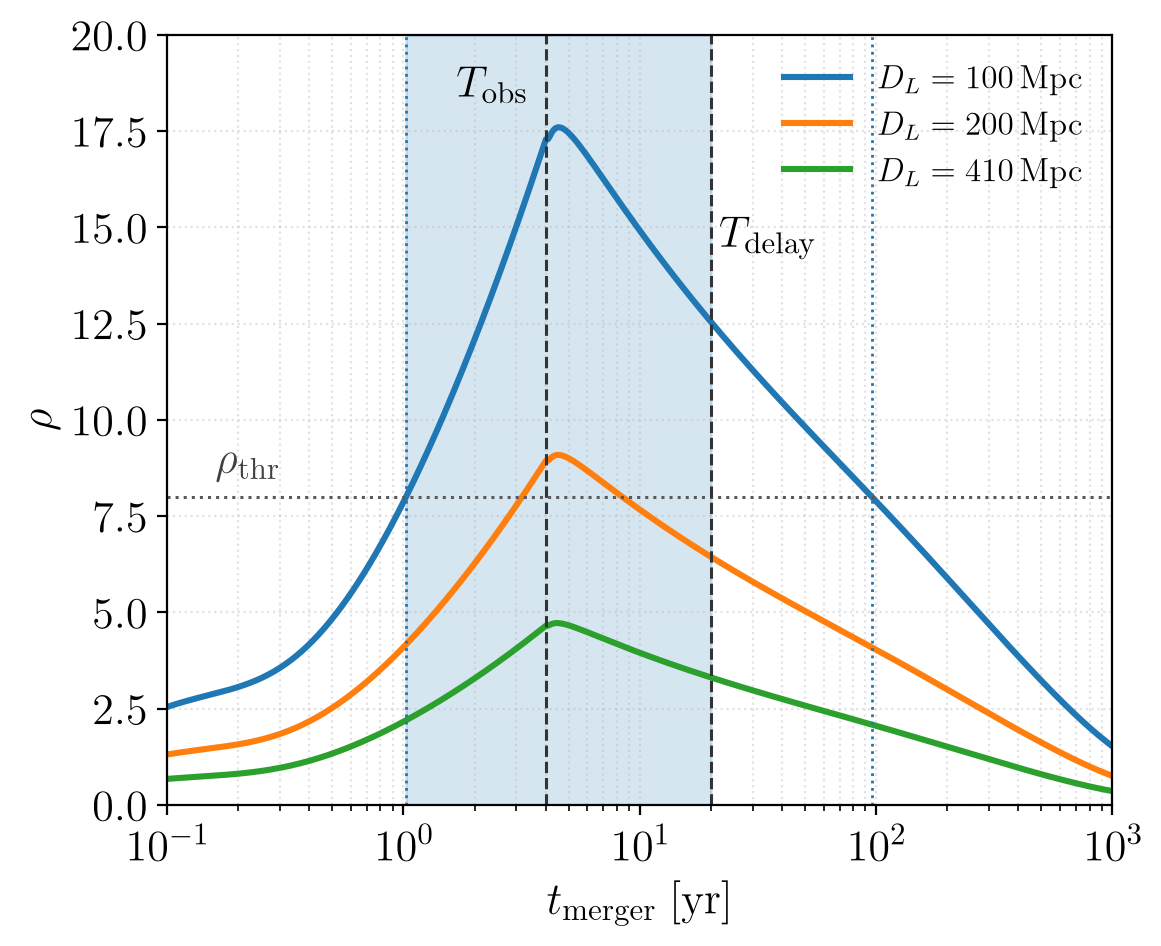

In [3]:
# Reproduce Figure 1 of 1902.00021v2 using Eq. (7).

def snr_vs_merger_time(m1, m2, luminosity_distance_mpc, merger_times_yr, observation_years=4):
    """LISA SNR accumulated during a mission ending before merger, using PhenomA."""
    z = redshift_from_luminosity_distance(luminosity_distance_mpc)
    luminosity_distance = luminosity_distance_mpc * 1e6 * pc
    chirp_mass_redshifted = chirp_mass_source(m1, m2) * (1 + z)
    f_cut = 1 #phenoma_transition_frequencies(m1, m2, z)["f3"]
    observation_time = observation_years * year
    snr = np.zeros_like(merger_times_yr, dtype=float)

    for index, merger_time_yr in enumerate(merger_times_yr):
        merger_time = merger_time_yr * year
        f_start = frequency_before_merger(merger_time, chirp_mass_redshifted)
        if merger_time > observation_time:
            f_stop = frequency_before_merger(merger_time - observation_time, chirp_mass_redshifted)
        else:
            f_stop = f_cut
        f_stop = min(f_stop, f_cut)

        if not (np.isfinite(f_start) and np.isfinite(f_stop)) or f_stop <= f_start:
            continue

        frequencies = np.logspace(np.log10(f_start), np.log10(f_stop), 2000)
        h_tilde = phenoma_fourier_amplitude(frequencies, m1, m2, z, luminosity_distance)
        integrand = h_tilde**2 / lisa_psd(frequencies, include_confusion=True, observation_years=observation_years)
        # PhenomA uses the polarization amplitude A(f). With the Robson et al.
        # sky-averaged LISA sensitivity curve, averaging over binary inclination
        # gives Eq. (18) of 1803.01944v2: rho^2 = (16/5) int A(f)^2/S_n(f) df.
        snr[index] = np.sqrt((16 / 5) * np.trapezoid(integrand, frequencies))

    return z, snr


def threshold_crossings(x, y, threshold):
    crossings = []
    values = y - threshold
    for i in range(len(x) - 1):
        if not (np.isfinite(values[i]) and np.isfinite(values[i + 1])):
            continue
        if values[i] == 0:
            crossings.append(x[i])
        elif values[i] * values[i + 1] < 0:
            logx0, logx1 = np.log10(x[i]), np.log10(x[i + 1])
            frac = -values[i] / (values[i + 1] - values[i])
            crossings.append(10 ** (logx0 + frac * (logx1 - logx0)))
    return crossings


merger_times = np.logspace(-1, 3, 500)
source_masses = (36, 29)
distances = [100.0, 200.0, 410.0]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
curves = []

for distance in distances:
    z, snr = snr_vs_merger_time(*source_masses, distance, merger_times, observation_years=4)
    curves.append((distance, z, snr))
    print(f"D_L={distance:.0f} Mpc, z={z:.4f}, max rho={np.nanmax(snr):.2f} at t={merger_times[np.nanargmax(snr)]:.2f} yr")

fig, ax = plt.subplots(figsize=(6.1, 5.0))
for (distance, z, snr), color in zip(curves, colors):
    ax.plot(merger_times, snr, color=color, lw=2.2, label=rf"$D_L={distance:.0f}\,\mathrm{{Mpc}}$")

threshold = 8.0
observation_years = 4.0
wait_years = 20.0
ax.axhline(threshold, color="0.35", ls=":", lw=1.1)
ax.axvline(observation_years, color="0.2", ls="--", lw=1.1)
ax.axvline(wait_years, color="0.2", ls="--", lw=1.1)
ax.text(0.16, threshold * 1.08, r"$\rho_{\rm thr}$", color="0.25")
ax.text(observation_years * 0.83, 18.4, r"$T_{\rm obs}$", ha="right")
ax.text(wait_years * 1.08, 14.5, r"$T_{\rm delay}$", ha="left")

# Shade the effective time window for the D_L=100 Mpc curve, matching the visual cue in the paper.
crossings = threshold_crossings(merger_times, curves[0][2], threshold)
if len(crossings) >= 2:
    ax.axvspan(crossings[0], min(crossings[-1], wait_years), color=colors[0], alpha=0.18)
    for crossing in (crossings[0], crossings[-1]):
        ax.axvline(crossing, color=colors[0], ls=":", lw=1.0)

ax.set_xscale("log")
ax.set_xlim(1e-1, 1e3)
ax.set_ylim(0, 20)
ax.set_xlabel(r"$t_{\rm merger}\;[\mathrm{yr}]$")
ax.set_ylabel(r"$\rho$")
ax.legend(loc="upper right", frameon=False, fontsize=12)
ax.grid(True, which="both", alpha=0.35)
fig.savefig("../plots/figure1_reproduction.png", dpi=220, bbox_inches="tight")
plt.show()


D_L=150 Mpc, z=0.0330, max rho=11.93 at t=4.56 yr


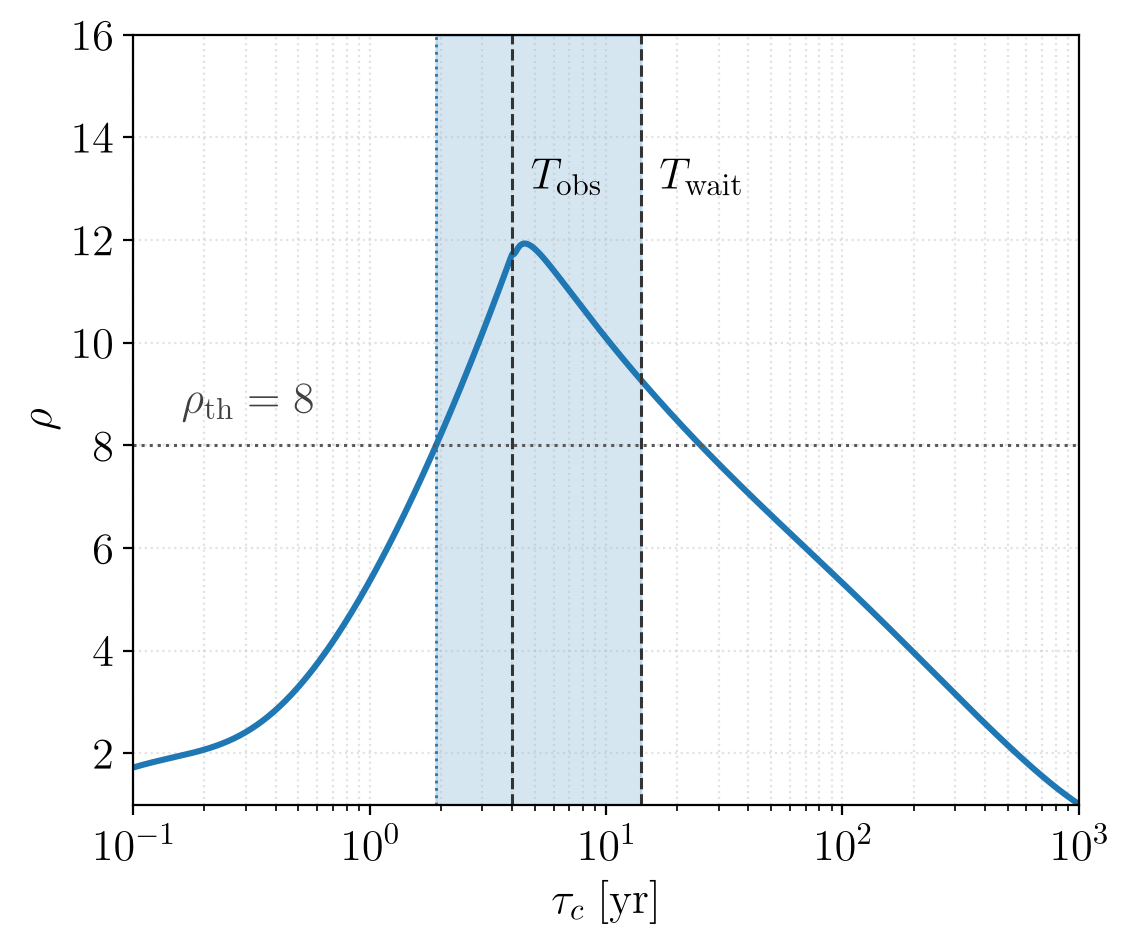

In [7]:
merger_times = np.logspace(-1, 3, 500)
source_masses = (36, 29)
distances = [150]
colors = ["#1f77b4"]
curves = []

for distance in distances:
    z, snr = snr_vs_merger_time(*source_masses, distance, merger_times, observation_years=4)
    curves.append((distance, z, snr))
    print(f"D_L={distance:.0f} Mpc, z={z:.4f}, max rho={np.nanmax(snr):.2f} at t={merger_times[np.nanargmax(snr)]:.2f} yr")

fig, ax = plt.subplots(figsize=(6.1, 5.0))
for (distance, z, snr), color in zip(curves, colors):
    ax.plot(merger_times, snr, color=color, lw=2.2, label="LISA")

threshold = 8.0
observation_years = 4.0
wait_years = 14.0
ax.axhline(threshold, color="0.35", ls=":", lw=1.1)
ax.axvline(observation_years, color="0.2", ls="--", lw=1.1)
ax.axvline(wait_years, color="0.2", ls="--", lw=1.1)
ax.text(0.16, threshold * 1.08, r"$\rho_{\rm th}=8$", color="0.25")
ax.text(observation_years * 1.2, 13, r"$T_{\rm obs}$", ha="left")
ax.text(wait_years * 1.2, 13, r"$T_{\rm wait}$", ha="left")

# Shade the effective time window for the D_L=100 Mpc curve, matching the visual cue in the paper.
crossings = threshold_crossings(merger_times, curves[0][2], threshold)
if len(crossings) >= 2:
    ax.axvspan(crossings[0], min(crossings[-1], wait_years), color=colors[0], alpha=0.18)
    # for crossing in (crossings[0], crossings[-1]):
    ax.axvline(crossings[0], color=colors[0], ls=":", lw=1.0)

ax.set_xscale("log")
ax.set_xlim(1e-1, 1e3)
ax.set_ylim(1,16)
ax.set_xlabel(r"$\tau_c\;[\mathrm{yr}]$")
ax.set_ylabel(r"$\rho$")
# ax.set_title(r"GW150914-like, $D_L=150\,\mathrm{Mpc}$", fontsize=14)
# ax.legend(loc="upper right", frameon=False, fontsize=12)
ax.grid(True, which="both", alpha=0.35)
fig.savefig("../plots/figure1_reproduction_150.png", dpi=220, bbox_inches="tight")
plt.show()


In [5]:
import test_notebook_functions as tnf
def snr_vs_merger_time(m1, m2, luminosity_distance_mpc, merger_times_yr, detector, observation_years=4):
    """LISA SNR accumulated during a mission ending before merger, using PhenomA."""
    z = redshift_from_luminosity_distance(luminosity_distance_mpc)
    luminosity_distance = luminosity_distance_mpc * 1e6 * pc
    chirp_mass_redshifted = chirp_mass_source(m1, m2) * (1 + z)
    if detector == "DECIGO":
        f_cut = 100.0
    elif detector == "AMIGO":
        f_cut = 10.0
    else:
        f_cut = 1.0
    observation_time = observation_years * year
    snr = np.zeros_like(merger_times_yr, dtype=float)

    for index, merger_time_yr in enumerate(merger_times_yr):
        merger_time = merger_time_yr * year
        f_start = frequency_before_merger(merger_time, chirp_mass_redshifted)
        if merger_time > observation_time:
            f_stop = frequency_before_merger(merger_time - observation_time, chirp_mass_redshifted)
        else:
            f_stop = f_cut
        f_stop = min(f_stop, f_cut)

        if not (np.isfinite(f_start) and np.isfinite(f_stop)) or f_stop <= f_start:
            continue

        frequencies = np.logspace(np.log10(f_start), np.log10(f_stop), 2000)
        h_tilde = phenoma_fourier_amplitude(frequencies, m1, m2, z, luminosity_distance)
        if detector == "LISA":
            integrand = h_tilde**2 / tnf.lisa_psd(frequencies, include_confusion=True, observation_years=observation_years)
        if detector == "Taiji":
            integrand = h_tilde**2 / tnf.taiji_psd(frequencies, include_confusion=True, observation_years=observation_years)
        if detector == "TianQin":
            integrand = h_tilde**2 / tnf.tianqin_psd(frequencies, observation_years=observation_years)
        elif detector == "DECIGO":
            integrand = h_tilde**2 / tnf.DECIGO_psd(frequencies)
        elif detector == "AMIGO":
            integrand = h_tilde**2 / tnf.amigo_psd(frequencies)
        #PhenomA uses the polarization amplitude A(f). With the Robson et al.
        # sky-averaged LISA sensitivity curve, averaging over binary inclination
        # gives Eq. (18) of 1803.01944v2: rho^2 = (16/5) int A(f)^2/S_n(f) df.
        snr[index] = np.sqrt((16 / 5) * np.trapezoid(integrand, frequencies))

    return z, snr

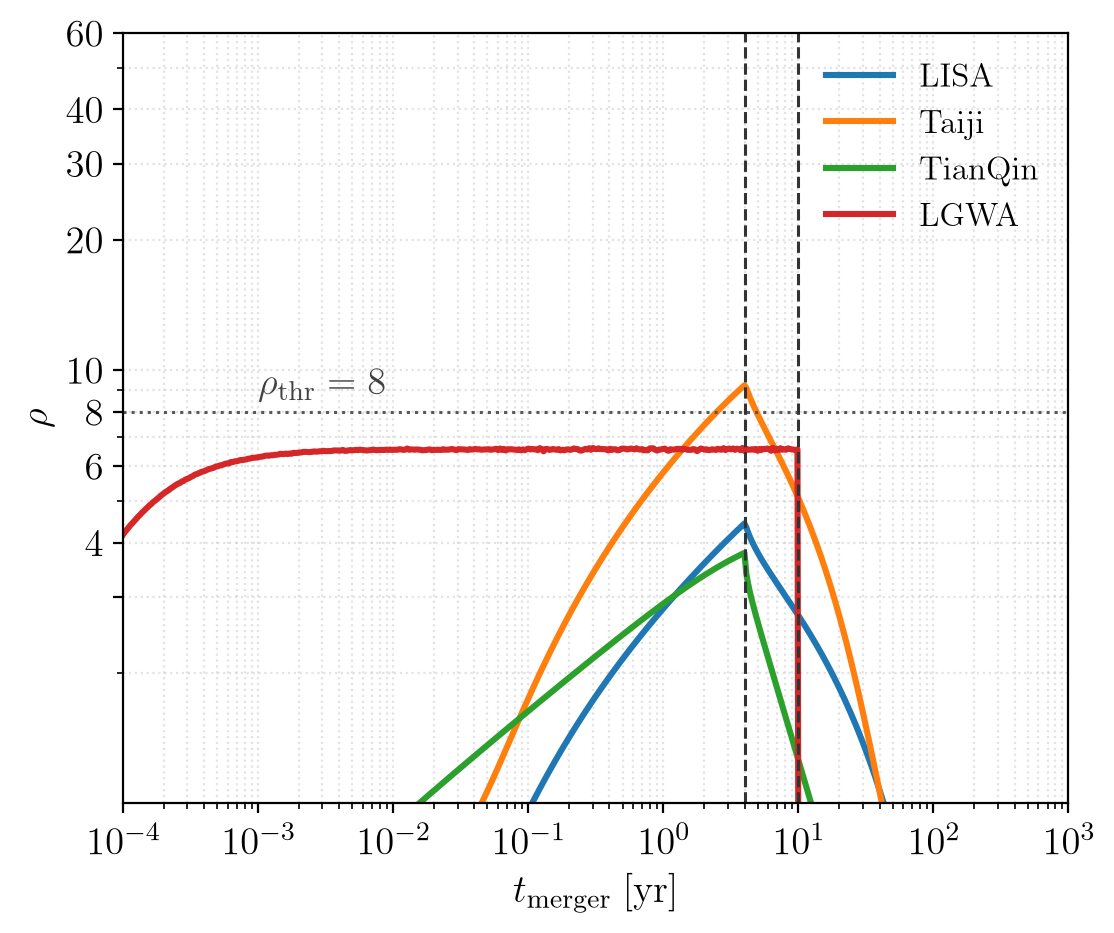

In [8]:
import test_notebook_functions as tnf
merger_times = np.logspace(-4, 3, 500)
source_masses = (100, 100)
distance = 4000
curves = []
detectors = ["LISA", "Taiji", "TianQin"]

for detector in detectors:
    z, snr = snr_vs_merger_time(*source_masses, distance, merger_times, detector=detector, observation_years=4)
    curves.append((detector, snr))

fig, ax = plt.subplots(figsize=(6.1, 5.0))
for (detector, snr) in curves:
    ax.plot(merger_times, snr, lw=2.2, label=rf"{detector}")

z,snr = tnf.snr_vs_merger_time_lgwa(*source_masses, distance, merger_times, observation_years=10)
ax.plot(merger_times, snr, lw=2.2, label=rf"LGWA")

threshold = 8.0
observation_years = 4.0
wait_years = 20.0
ax.axhline(threshold, color="0.35", ls=":", lw=1.1)
# ax.axhline(4, color="0.35", ls=":", lw=1.1)
ax.axvline(observation_years, color="0.2", ls="--", lw=1.1)
ax.axvline(10, color="0.2", ls="--", lw=1.1)
# ax.axvline(wait_years, color="0.2", ls="--", lw=1.1)
ax.text(1e-3, threshold * 1.1, r"$\rho_{\rm thr}=8$", color="0.25")
# ax.text(0.16, 4 * 1.08, r"$\rho_{\rm thr}=4$", color="0.25")
# ax.text(observation_years * 2.1, 7., r"$T_{\rm obs}$", ha="right")
# ax.text(wait_years * 1.2, 7, r"$T_{\rm delay}$", ha="left")

# Shade the effective time window for the D_L=100 Mpc curve, matching the visual cue in the paper.
# crossings = threshold_crossings(merger_times, curves[0][1], threshold)
# if len(crossings) >= 2:
#     ax.axvspan(crossings[0], min(crossings[-1], wait_years), color=colors[0], alpha=0.18)
#     for crossing in (crossings[0], crossings[-1]):
#         ax.axvline(crossing, color=colors[0], ls=":", lw=1.0)

plt.rcParams.update({"font.size": 14})
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-4, 1e3)
ax.set_ylim(1)
ax.set_xlabel(r"$t_{\rm merger}\;[\mathrm{yr}]$")
ax.set_ylabel(r"$\rho$")
ax.set_yticks([3,4,6, 8, 10,20,30,40,60], labels=[" ", r"$4$",r"$6$", r"$8$", r"$10$", r"$20$", r"$30$", r"$40$", r"$60$"])
ax.legend(loc="upper right", frameon=False, fontsize=12)
ax.grid(True, which="both", alpha=0.35)

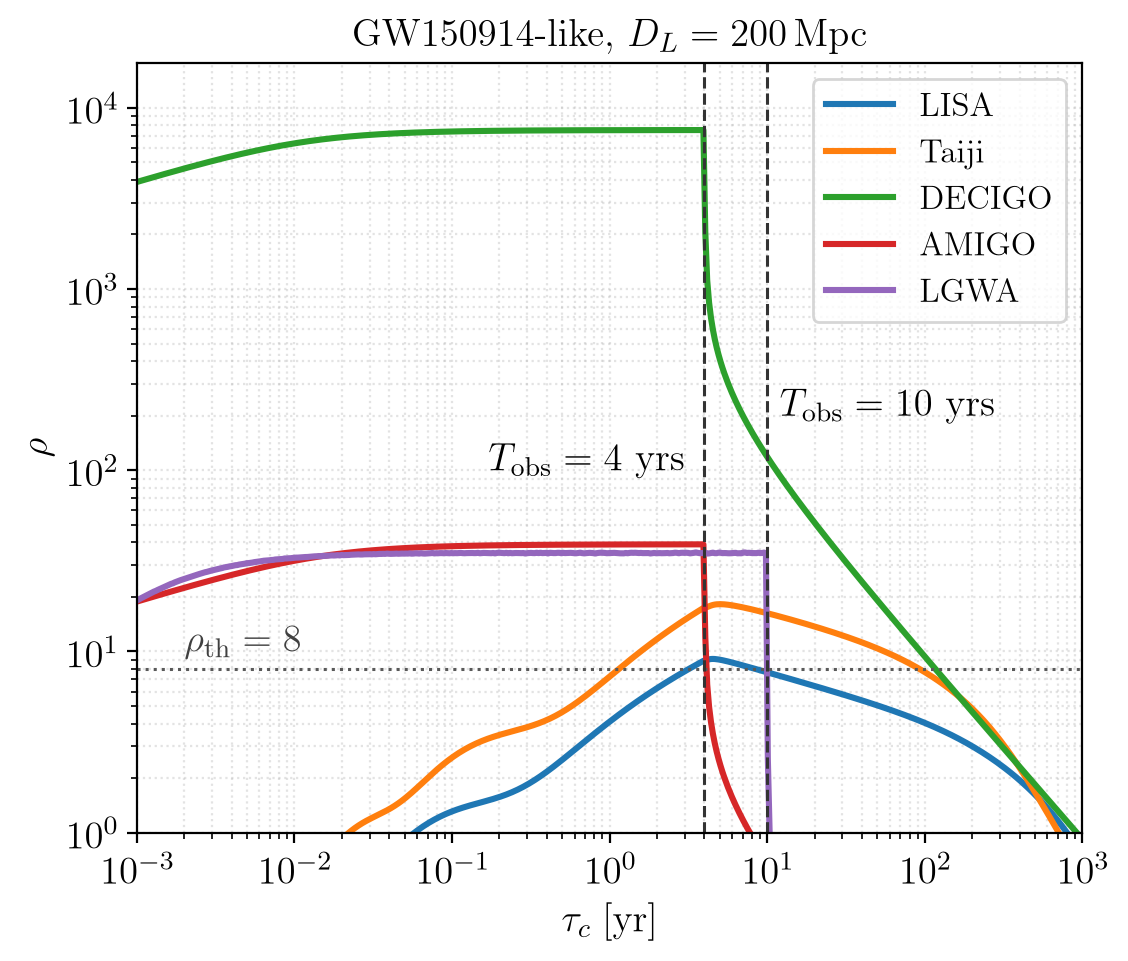

In [9]:
import test_notebook_functions as tnf
merger_times = np.logspace(-3, 3, 500)
source_masses = (36, 29)
distance = 200
curves = []
detectors = ["LISA", "Taiji", 'DECIGO', 'AMIGO']

for detector in detectors:
    z, snr = snr_vs_merger_time(*source_masses, distance, merger_times, detector=detector, observation_years=4)
    curves.append((detector, snr))

fig, ax = plt.subplots(figsize=(6.1, 5.0))
for (detector, snr) in curves:
    ax.plot(merger_times, snr, lw=2.2, label=rf"{detector}")

z,snr = tnf.snr_vs_merger_time_lgwa(*source_masses, distance, merger_times, observation_years=10)
ax.plot(merger_times, snr, lw=2.2, label=rf"LGWA")

threshold = 8.0
observation_years = 4.0
wait_years = 20.0
ax.axhline(threshold, color="0.35", ls=":", lw=1.1)
# ax.axhline(4, color="0.35", ls=":", lw=1.1)
ax.axvline(observation_years, color="0.2", ls="--", lw=1.1)
ax.axvline(10, color="0.2", ls="--", lw=1.1)
# ax.axvline(wait_years, color="0.2", ls="--", lw=1.1)
ax.text(2e-3, 10, r"$\rho_{\rm th}=8$", color="0.25")
# ax.text(0.16, 4 * 1.08, r"$\rho_{\rm thr}=4$", color="0.25")
ax.text(3, 100, r"$T_{\rm obs}=4$ yrs", ha="right")
ax.text(12, 200, r"$T_{\rm obs}=10$ yrs", ha="left")
# ax.text(wait_years * 1.2, 7, r"$T_{\rm delay}$", ha="left")

# Shade the effective time window for the D_L=100 Mpc curve, matching the visual cue in the paper.
# crossings = threshold_crossings(merger_times, curves[0][1], threshold)
# if len(crossings) >= 2:
#     ax.axvspan(crossings[0], min(crossings[-1], wait_years), color=colors[0], alpha=0.18)
#     for crossing in (crossings[0], crossings[-1]):
#         ax.axvline(crossing, color=colors[0], ls=":", lw=1.0)

plt.rcParams.update({"font.size": 14})
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e3)
ax.set_ylim(1)
ax.set_xlabel(r"$\tau_c\;[\mathrm{yr}]$")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"GW150914-like, $D_L=200\,\mathrm{Mpc}$", fontsize=14)
# ax.set_yticks([3,4,6, 8, 10,20,30,40,60], labels=[" ", r"$4$",r"$6$", r"$8$", r"$10$", r"$20$", r"$30$", r"$40$", r"$60$"])
ax.legend(loc="upper right", fontsize=12)
ax.grid(True, which="both", alpha=0.35)
plt.savefig("../plots/figure1_reproduction_detectors.png", dpi=220, bbox_inches="tight")

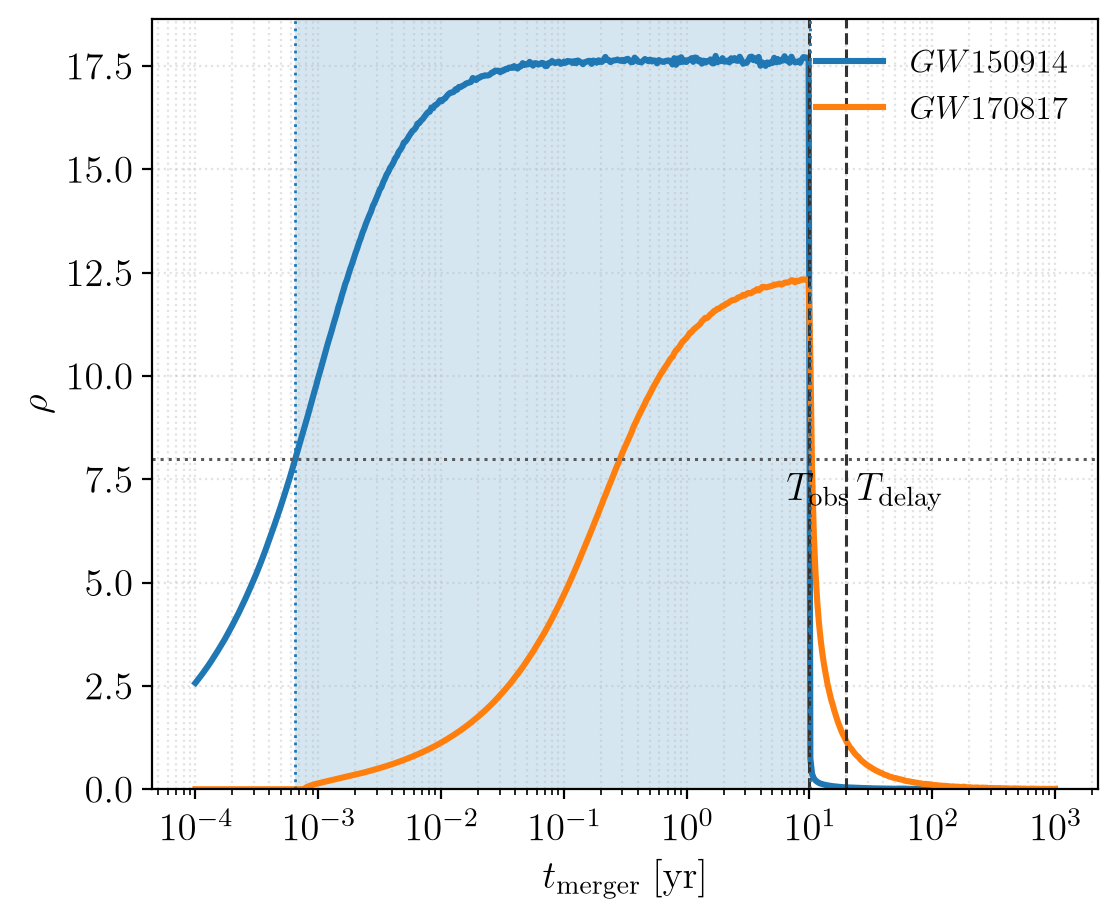

In [11]:
import test_notebook_functions as tnf

merger_times = np.logspace(-4, 3, 500)
source_masses_1 = (36, 29)
source_masses_2 = (1.4, 1.4)
distance_1 = 410
distance_2 = 40

z1, snr1 = tnf.snr_vs_merger_time_lgwa(*source_masses_1, distance_1, merger_times)
z2, snr2 = tnf.snr_vs_merger_time_lgwa(*source_masses_2, distance_2, merger_times)

fig, ax = plt.subplots(figsize=(6.1, 5.0))
ax.plot(merger_times, snr1, lw=2.2, label=r"$GW150914$")
ax.plot(merger_times, snr2, lw=2.2, label=r"$GW170817$")

threshold = 8.0
wait_years = 20.0
observation_years = 10
ax.axhline(threshold, color="0.35", ls=":", lw=1.1)
# ax.axhline(4, color="0.35", ls=":", lw=1.1)
ax.axvline(observation_years, color="0.2", ls="--", lw=1.1)
ax.axvline(wait_years, color="0.2", ls="--", lw=1.1)
# ax.text(0.16, threshold * 1.04, r"$\rho_{\rm thr}=8$", color="0.25")
# ax.text(0.16, 4 * 1.08, r"$\rho_{\rm thr}=4$", color="0.25")
ax.text(observation_years * 2.1, 7., r"$T_{\rm obs}$", ha="right")
ax.text(wait_years * 1.2, 7, r"$T_{\rm delay}$", ha="left")

# Shade the effective time window for the D_L=100 Mpc curve, matching the visual cue in the paper.
crossings = tnf.threshold_crossings(merger_times, snr1, threshold)
if len(crossings) >= 2:
    ax.axvspan(crossings[0], min(crossings[-1], wait_years), alpha=0.18)
    for crossing in (crossings[0], crossings[-1]):
        ax.axvline(crossing, ls=":", lw=1.0)

plt.rcParams.update({"font.size": 14})
ax.set_xscale("log")
# ax.set_xlim(1e-1, 1e2)
ax.set_ylim(0)
ax.set_xlabel(r"$t_{\rm merger}\;[\mathrm{yr}]$")
ax.set_ylabel(r"$\rho$")
ax.legend(loc="upper right", frameon=False, fontsize=12)
ax.grid(True, which="both", alpha=0.35)

/tmp/ipykernel_8110/1148551931.py:20: RuntimeWarning: overflow encountered in exp
  f = np.exp(delta_m / mprime + delta_m / (mprime - delta_m))


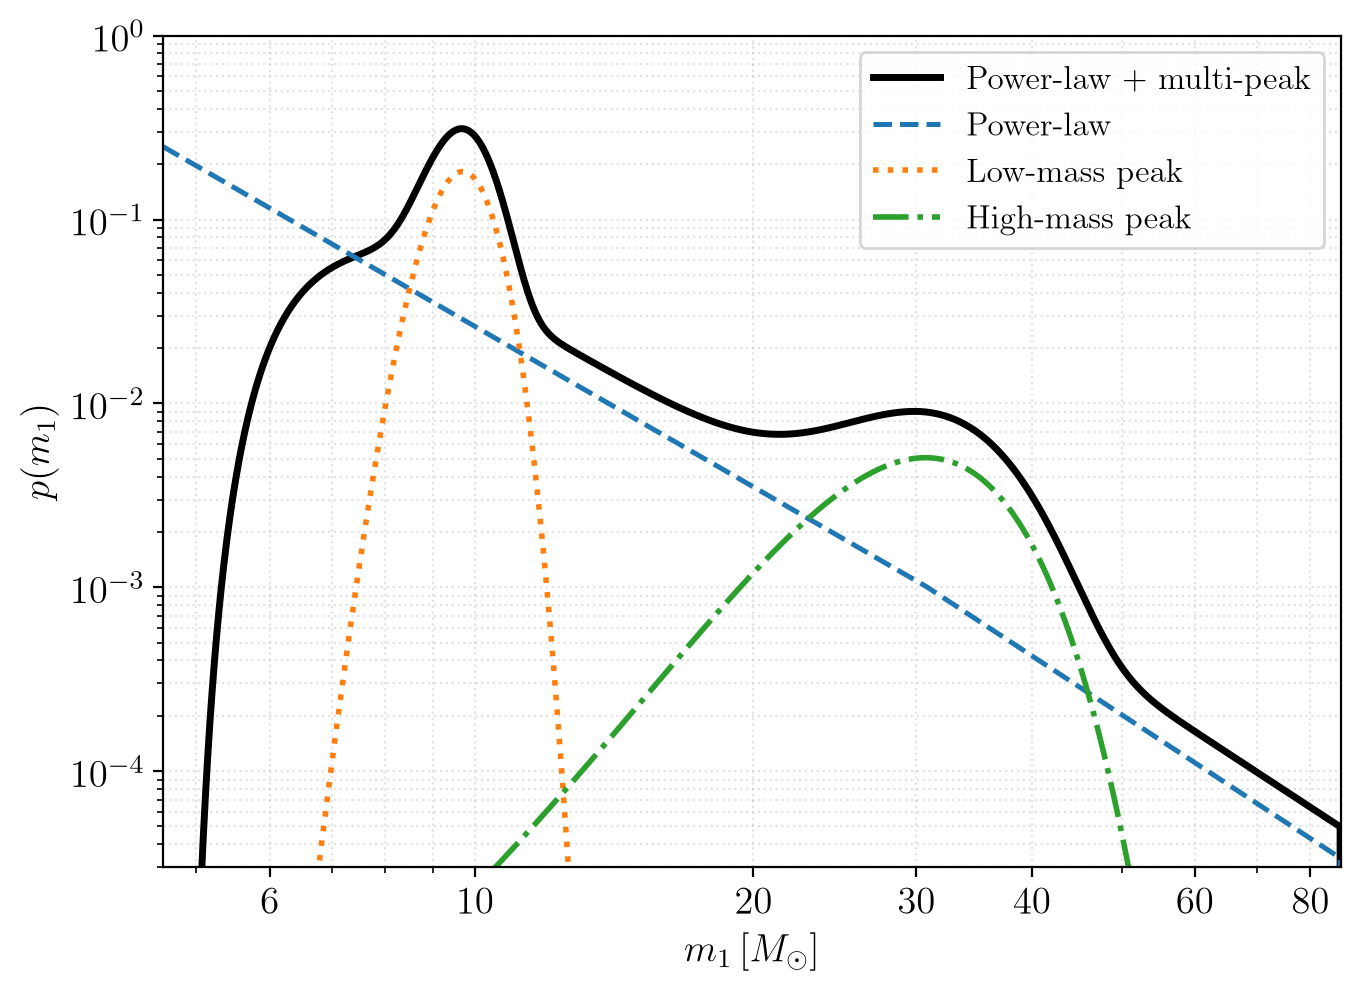

Saved ../plots/fullpop40_mass_model.png
Using Table II values: {'alpha': 2.9, 'm_min': 4.6, 'm_max': 86.3, 'delta_m': 4.8, 'mu_g_low': 9.7, 'sigma_g_low': 0.7, 'mu_g_high': 30.7, 'sigma_g_high': 6.3, 'lambda_g': 0.4, 'lambda_g_low': 0.8, 'gamma': 3.3, 'beta_q': 1.0, 'kappa': 2.9, 'z_p': 2.5}


In [24]:
# Plot the GWTC-4.0 / FullPop-4.0 BBH mass model using injected parameters from
# Table II of GPUcosmo_PRD_manuscript-8.pdf and the Broken Power Law + 2 Peaks
# form described in Appendix B.3 of 2508.18083v2.

import math
from pathlib import Path


def smooth_taper(m, m_low, delta_m):
    """Low-mass taper S(m | m_low, delta_m) from Eq. (B21)."""
    m = np.asarray(m, dtype=float)
    out = np.zeros_like(m)
    if delta_m <= 0:
        out[m >= m_low] = 1.0
        return out
    mid = (m > m_low) & (m < m_low + delta_m)
    hi = m >= m_low + delta_m
    out[hi] = 1.0
    mprime = m[mid] - m_low
    f = np.exp(delta_m / mprime + delta_m / (mprime - delta_m))
    out[mid] = 1.0 / (1.0 + f)
    return out


def truncated_normal_pdf(x, mu, sigma, low, high=np.inf):
    x = np.asarray(x, dtype=float)
    pdf = np.zeros_like(x)
    if sigma <= 0:
        return pdf

    alpha = (low - mu) / sigma
    beta = (high - mu) / sigma if np.isfinite(high) else np.inf
    cdf_alpha = 0.5 * (1.0 + math.erf(alpha / math.sqrt(2.0)))
    cdf_beta = 1.0 if not np.isfinite(beta) else 0.5 * (1.0 + math.erf(beta / math.sqrt(2.0)))
    norm = sigma * math.sqrt(2.0 * math.pi) * (cdf_beta - cdf_alpha)
    mask = (x >= low) & (x <= high)
    pdf[mask] = np.exp(-0.5 * ((x[mask] - mu) / sigma) ** 2) / norm
    return pdf


def broken_power_law_pdf(m, alpha1, alpha2, m_break, m_low, m_high):
    """Eq. (B18), normalized numerically over [m_low, m_high]."""
    m = np.asarray(m, dtype=float)
    pdf = np.zeros_like(m)
    mask1 = (m >= m_low) & (m < m_break)
    mask2 = (m >= m_break) & (m < m_high)
    pdf[mask1] = (m[mask1] / m_break) ** (-alpha1)
    pdf[mask2] = (m[mask2] / m_break) ** (-alpha2)

    grid = np.geomspace(m_low, m_high, 4000)
    grid_pdf = np.where(
        grid < m_break,
        (grid / m_break) ** (-alpha1),
        (grid / m_break) ** (-alpha2),
    )
    norm = np.trapezoid(grid_pdf, grid)
    return pdf / norm


def fullpop40_primary_mass_pdf(m, params):
    """Approximate FullPop-4.0 BBH primary-mass model using the default BBH mass model.

    Following 2508.18083v2 Appendix B.3, we use the Broken Power Law + 2 Peaks
    model with a common low-mass taper applied to the full distribution. The GPUcosmo
    injected set provides one peak fraction `lambda_g` and low-peak split `lambda_g_low`;
    thus the peak weights are
      lambda_1 = lambda_g * lambda_g_low
      lambda_2 = lambda_g * (1 - lambda_g_low)
      lambda_0 = 1 - lambda_g
    We use `gamma` as the high-mass spectral index and, in the absence of an injected
    break value in Table II, take the continuum break at the high-mass peak location.
    """
    alpha1 = params['alpha']
    alpha2 = params['gamma']
    m_break = params['mu_g_high']
    m_low = params['m_min']
    m_high = params['m_max']

    lambda_g = params['lambda_g']
    lambda_g_low = params['lambda_g_low']
    lambda0 = 1.0 - lambda_g
    lambda1 = lambda_g * lambda_g_low
    lambda2 = lambda_g * (1.0 - lambda_g_low)

    pl = broken_power_law_pdf(m, alpha1, alpha2, m_break, m_low, m_high)
    peak1 = truncated_normal_pdf(m, params['mu_g_low'], params['sigma_g_low'], low=m_low, high=m_high)
    peak2 = truncated_normal_pdf(m, params['mu_g_high'], params['sigma_g_high'], low=m_low, high=m_high)
    taper = smooth_taper(m, m_low, params['delta_m'])
    raw = (lambda0 * pl + lambda1 * peak1 + lambda2 * peak2) * taper

    grid = np.geomspace(m_low, m_high, 5000)
    pl_g = broken_power_law_pdf(grid, alpha1, alpha2, m_break, m_low, m_high)
    peak1_g = truncated_normal_pdf(grid, params['mu_g_low'], params['sigma_g_low'], low=m_low, high=m_high)
    peak2_g = truncated_normal_pdf(grid, params['mu_g_high'], params['sigma_g_high'], low=m_low, high=m_high)
    taper_g = smooth_taper(grid, m_low, params['delta_m'])
    raw_g = (lambda0 * pl_g + lambda1 * peak1_g + lambda2 * peak2_g) * taper_g
    norm = np.trapezoid(raw_g, grid)
    return raw / norm


injected = {
    'alpha': 2.9,
    'm_min': 4.6,
    'm_max': 86.3,
    'delta_m': 4.8,
    'mu_g_low': 9.7,
    'sigma_g_low': 0.7,
    'mu_g_high': 30.7,
    'sigma_g_high': 6.3,
    'lambda_g': 0.4,
    'lambda_g_low': 0.8,
    'gamma': 3.3,
    'beta_q': 1.0,
    'kappa': 2.9,
    'z_p': 2.5,
}

m_grid = np.geomspace(injected['m_min'], injected['m_max'], 1600)
pdf_fullpop = fullpop40_primary_mass_pdf(m_grid, injected)

lambda1 = injected['lambda_g'] * injected['lambda_g_low']
lambda2 = injected['lambda_g'] * (1.0 - injected['lambda_g_low'])
lambda0 = 1.0 - injected['lambda_g']

fig, ax = plt.subplots(figsize=(7.6, 5.4))
ax.plot(m_grid, pdf_fullpop, color='black', lw=2.5, label='Power-law + multi-peak')
ax.plot(
    m_grid,
    lambda0 * broken_power_law_pdf(m_grid, injected['alpha'], injected['gamma'], injected['mu_g_high'], injected['m_min'], injected['m_max']),
    color='#1f77b4',
    ls='--',
    lw=1.8,
    label='Power-law',
)
ax.plot(
    m_grid,
    lambda1 * truncated_normal_pdf(m_grid, injected['mu_g_low'], injected['sigma_g_low'], low=injected['m_min'], high=injected['m_max']),
    color='#ff7f0e',
    ls=':',
    lw=2.0,
    label='Low-mass peak',
)
ax.plot(
    m_grid,
    lambda2 * truncated_normal_pdf(m_grid, injected['mu_g_high'], injected['sigma_g_high'], low=injected['m_min'], high=injected['m_max']),
    color='#2ca02c',
    ls='-.',
    lw=2.0,
    label='High-mass peak',
)

# for xval, label in [
#     (injected['m_min'], r'$m_{\min}$'),
#     (injected['mu_g_low'], r'$\mu_{g,\mathrm{low}}$'),
#     (injected['mu_g_high'], r'$\mu_{g,\mathrm{high}}$'),
#     (injected['m_max'], r'$m_{\max}$'),
# ]:
#     ax.axvline(xval, color='0.65', lw=0.8, alpha=0.8)
#     ax.text(xval, ax.get_ylim()[1] * 0.92, label, rotation=90, va='top', ha='right', color='0.35')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_1\,[M_\odot]$')
ax.set_ylabel(r'$p(m_1)$')
ax.set_xticks([6,10,20,30,40,60,80], labels=[r'$6$',r'$10$',r'$20$',r'$30$',r'$40$',r'$60$',r'$80$'])
ax.set_xlim(injected['m_min'], injected['m_max'])
ax.set_ylim(3e-5, 1)
# ax.set_title('Approximate FULLPOP-4.0 BBH primary-mass model')
ax.legend(fontsize=12)
ax.grid(True, which='both', alpha=0.35)

out = Path('../plots/fullpop40_mass_model.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=220, bbox_inches='tight')
plt.show()

print('Saved', out)
print('Using Table II values:', injected)


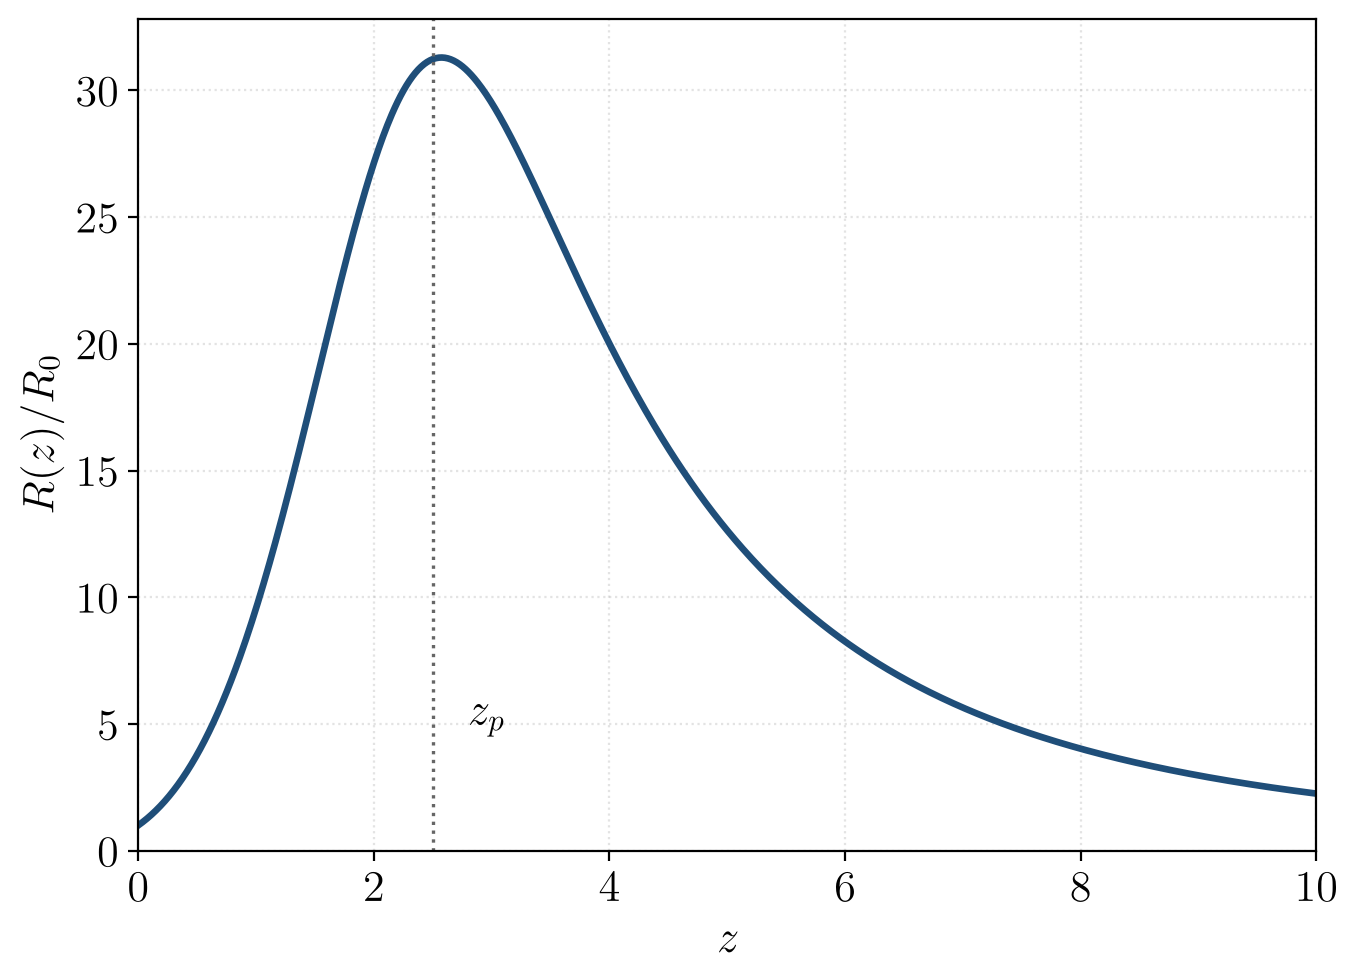

Saved ../plots/normalize_madau_merger_rate_vs_redshift.png
FullPop rate parameters: {'gamma': 3.3, 'kappa': 2.9, 'zp': 2.5}
R0 = 19 Gpc^-3 yr^-1, uncertainty range = [14, 26]


In [4]:
# Plot the FullPop Madau-Dickinson merger-rate density and its R0 uncertainty.

from pathlib import Path


def madau_dickinson_rate(z, gamma=3.3, kappa=2.9, zp=2.5, R0=1.0):
    """Madau-Dickinson merger-rate density normalized to R(0) = R0."""
    z = np.asarray(z, dtype=float)
    rate = (1.0 + z) ** gamma / (1.0 + ((1.0 + z) / (1.0 + zp)) ** (gamma + kappa))
    return R0 * rate * (1.0 + (1.0 + zp) ** (- gamma - kappa))

injected = {
    'alpha': 2.9,
    'm_min': 4.6,
    'm_max': 86.3,
    'delta_m': 4.8,
    'mu_g_low': 9.7,
    'sigma_g_low': 0.7,
    'mu_g_high': 30.7,
    'sigma_g_high': 6.3,
    'lambda_g': 0.4,
    'lambda_g_low': 0.8,
    'gamma': 3.3,
    'beta_q': 1.0,
    'kappa': 2.9,
    'z_p': 2.5,
}
fullpop_rate_parameters = {
    'gamma': injected['gamma'],
    'kappa': injected['kappa'],
    'zp': injected['z_p'],
}
R0_central = 19.0
R0_low = 14.0
R0_high = 26.0

z_grid = np.linspace(0.0, 10.0, 800)
rate_madau = madau_dickinson_rate(z_grid, R0=R0_central, **fullpop_rate_parameters)
rate_madau_low = madau_dickinson_rate(z_grid, R0=R0_low, **fullpop_rate_parameters)
rate_madau_high = madau_dickinson_rate(z_grid, R0=R0_high, **fullpop_rate_parameters)

fig, ax = plt.subplots(figsize=(7.6, 5.4))
# ax.fill_between(
#     z_grid, rate_madau_low, rate_madau_high,
#     color='#4c78a8', alpha=0.25, label=rf'$R_0={R0_low:.0f}$--${R0_high:.0f}$ uncertainty',
# )
ax.plot(z_grid, rate_madau/R0_central, color='#1f4e79', lw=2.4, label=rf'$R_0={R0_central:.0f}$')
ax.axvline(injected['z_p'], color='0.4', lw=1.2, ls=':', label=rf'$z_p={injected["z_p"]}$')
# ax.text(3.5, 720, rf'$z_p={injected["z_p"]}$', ha="left")
ax.text(2.8, 5, rf'$z_p$', ha="left")

ax.set_xlim(0.0, 10.0)
ax.set_ylim(bottom=0.0)
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$R(z)/R_0$')
# ax.set_title('FullPop Madau merger rate')
# ax.legend(frameon=False, fontsize=12)
ax.grid(True, which='both', alpha=0.35)

out = Path('../plots/normalize_madau_merger_rate_vs_redshift.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=220, bbox_inches='tight')
plt.show()

print('Saved', out)
print('FullPop rate parameters:', fullpop_rate_parameters)
print(f'R0 = {R0_central:.0f} Gpc^-3 yr^-1, uncertainty range = [{R0_low:.0f}, {R0_high:.0f}]')
